I used Gemini with the guided learning enabled to help me with understanding, and walking me through the steps to solve everything while asking questions of me and I of it.


# Ex6.1

$\mathbb{E}(C_0) = \frac{1*4+0*3+0*5}{12} = \frac{4}{12}$

$\mathbb{E}(C_1) = \frac{0*4+1*3+0*5}{12} = \frac{3}{12}$



$\mathbb{E}(Y| X = 0) = \frac{1*2+0*0+0*4}{6} = \frac{2}{6}$

$\mathbb{E}(Y| X = 1) = \frac{0*2+1*3+0*1}{6} = \frac{3}{6}$


Avg treatment effect:

$$\theta = \mathbb{E}(C_1) - \mathbb{E}(C_0)$$

$$= \frac{3}{12} - \frac{4}{12} = -\frac{1}{12}$$


Association:

$$\alpha = \mathbb{E}(Y| X = 1) - \mathbb{E}(Y| X = 0)$$

$$= \frac{3}{6} - \frac{2}{6} = \frac{1}{6}$$

# Ex6.2


    Y=1   Y=0
X=1|15+20|25+m
X=0|5+20|10+10

    Y=1 Y=0
X=1|35|25+m
X=0|25|20


\begin{aligned}
    &\begin{array}{c|c|c|}
        Z=1  & Y=1 & Y=0  \\
        \hline \hline
        X=1 & 15 & 25 \\
        \hline
        X=0 & 5 & 10 \\
        \hline
    \end{array}
    &\begin{array}{c|c|c|}
        Z=0 & Y=1 & Y=0  \\
        \hline \hline
        X=1 & 20 & m \\
        \hline
        X=0 & 20 & 10 \\
        \hline
    \end{array}
\end{aligned}



\begin{aligned}
    &\begin{array}{c|c|c|}
        Z  & Y=1 & Y=0  \\
        \hline \hline
        X=1 & 35 & 25+m & 60+m \\
        \hline
        X=0 & 25 & 20 & 45 \\
        \hline \hline
         & 60 & 45+m
    \end{array}
\end{aligned}


---


$$P(Y=1 | X=1) - P(Y=1 | X=0)$$

$$= \frac{P(Y=1, X=1)}{P(X=1)} - \frac{P(Y=1, X=0)}{P(X=0)}$$

$$= \frac{35}{60+m} - \frac{25}{45}$$

m >= 4 negative results for whole group

---


$$P(Y=1 | X=1, Z=1) - P(Y=1 | X=0, Z=1)$$

$$= \frac{P(Y=1, X=1, Z=1)}{P(X=1, Z=1)} - \frac{P(Y=1, X=0, Z=1)}{P(X=0, Z=1)}$$

$$= \frac{15}{40} - \frac{5}{15}$$

$$= \frac{45}{120} - \frac{40}{120} $$

$$= \frac{5}{120} = \frac{1}{24} =  0.0417$$

---


$$P(Y=1 | X=1, Z=0) - P(Y=1 | X=0, Z=0)$$

$$= \frac{P(Y=1, X=1, Z=0)}{P(X=1, Z=0)} - \frac{P(Y=1, X=0, Z=0)}{P(X=0, Z=0)}$$

$$= \frac{20}{20+m} - \frac{20}{30}$$

m < 10 positive results

---


$$4 <= m <= 9$$


# Ex6.3

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
toys = pd.read_csv("toys.txt", sep='\t')

toys

,Full,MCAR,MAR,MNAR
0,-2.302,-0.831,NaN,NaN
1,1.091,1.272,0.205,1.419
2,-0.277,-0.116,-0.210,0.458
3,0.466,NaN,0.324,-0.559
4,0.020,1.013,-0.270,NaN
...,...,...,...,...
495,-0.658,NaN,NaN,-0.138
496,0.649,NaN,0.716,0.493
497,-0.157,-0.182,NaN,0.434
498,-1.772,-1.442,NaN,NaN


In [4]:
mean_full = np.mean(toys["Full"])
mean_mcar = np.mean(toys["MCAR"])
mean_mar = np.mean(toys["MAR"])
mean_mnar = np.mean(toys["MNAR"])

mean_full, mean_mcar, mean_mar, mean_mnar

(np.float64(-0.037666),
 np.float64(-0.07960843373493975),
 np.float64(0.3885646687697161),
 np.float64(0.436472891566265))

- The mean changes as the variable changes, growing from $X_1 to X_4$

## 2.

In [5]:
toys_present = toys.dropna()
toys_present

,Full,MCAR,MAR,MNAR
1,1.091,1.272,0.205,1.419
2,-0.277,-0.116,-0.210,0.458
5,0.449,0.117,0.473,1.134
8,-0.384,-0.612,-0.179,-0.066
14,-0.404,-0.767,-0.558,0.039
...,...,...,...,...
479,0.616,0.723,1.130,-0.722
486,0.250,0.398,-0.820,0.376
487,1.209,2.186,2.331,0.866
493,-0.519,-0.360,-1.026,-0.796


In [6]:
mean_full = np.mean(toys_present["Full"])
mean_mcar = np.mean(toys_present["MCAR"])
mean_mar = np.mean(toys_present["MAR"])
mean_mnar = np.mean(toys_present["MNAR"])

mean_full, mean_mcar, mean_mar, mean_mnar

(np.float64(0.5573614457831325),
 np.float64(0.45115662650602406),
 np.float64(0.4748975903614458),
 np.float64(0.5823373493975903))

- The means have evened out a lot, with $+- 0.1$ difference

## 3.

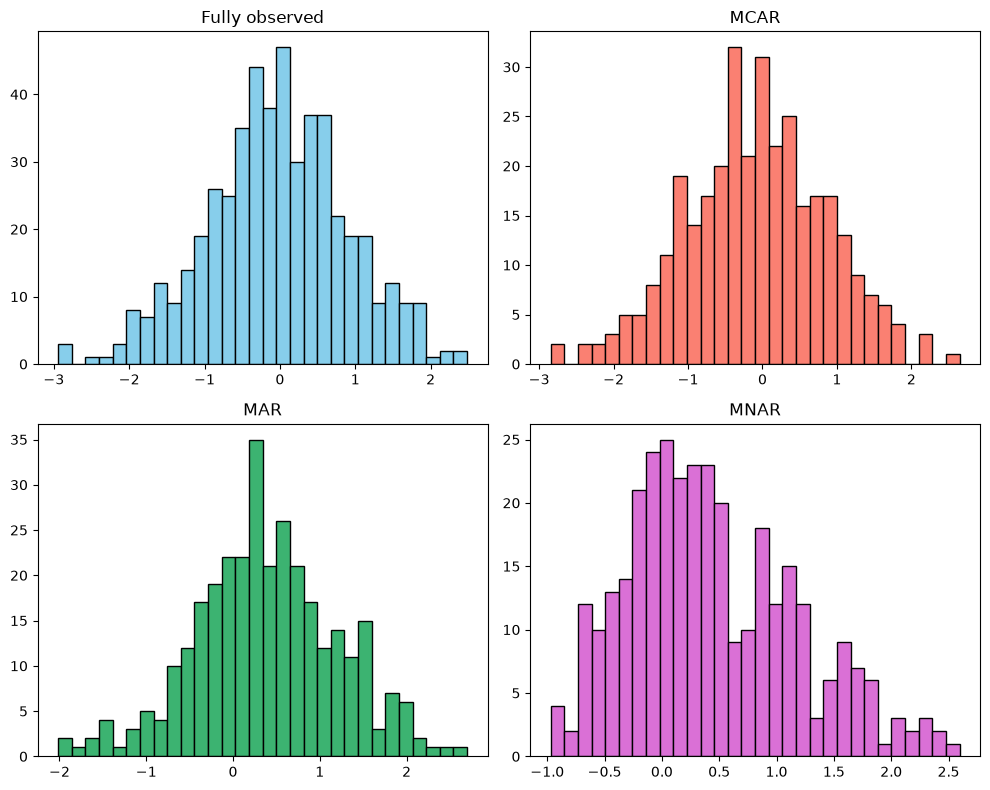

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))


axes[0, 0].hist(toys["Full"], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Fully observed')

axes[0, 1].hist(toys["MCAR"], bins=30, color='salmon', edgecolor='black')
axes[0, 1].set_title('MCAR')

axes[1, 0].hist(toys["MAR"], bins=30, color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('MAR')

axes[1, 1].hist(toys["MNAR"], bins=30, color='orchid', edgecolor='black')
axes[1, 1].set_title('MNAR')

plt.tight_layout()
plt.show()

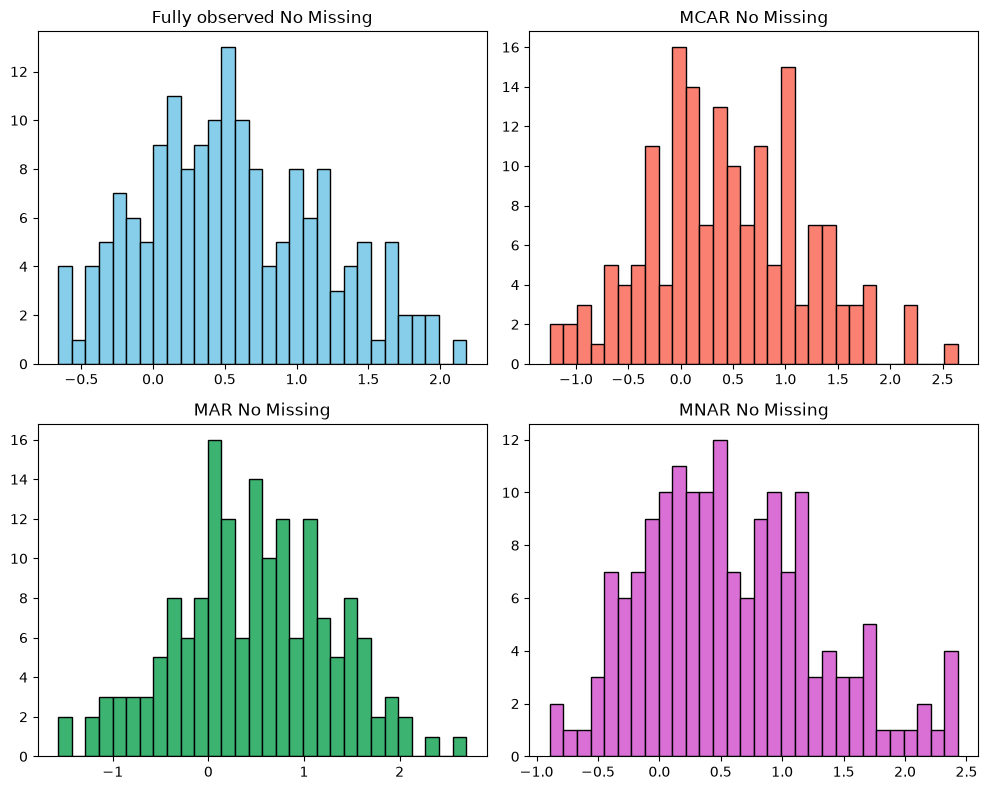

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))


axes[0, 0].hist(toys_present["Full"], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Fully observed No Missing')

axes[0, 1].hist(toys_present["MCAR"], bins=30, color='salmon', edgecolor='black')
axes[0, 1].set_title('MCAR No Missing')

axes[1, 0].hist(toys_present["MAR"], bins=30, color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('MAR No Missing')

axes[1, 1].hist(toys_present["MNAR"], bins=30, color='orchid', edgecolor='black')
axes[1, 1].set_title('MNAR No Missing')

plt.tight_layout()
plt.show()

- The missing values appear to help maintain an appearance of normal distribution shape for most except MNAR, which seems to get slightly more normal looking only if the missing values are ignored.
- All except MNAR seem to shift to the left a bit. Namely the X-axis' 0 shifts to the left
- Y-axis shrinks most drastically for the fully observed (from 40+ down to a bit over 12)
- 

## 4

In [9]:
corr = toys.corr(method="pearson")
corr_present = toys_present.corr(method="pearson")

display(corr)
corr_present

,Full,MCAR,MAR,MNAR
Full,1.000000,0.805627,0.651844,0.671106
MCAR,0.805627,1.000000,0.312451,0.443313
MAR,0.651844,0.312451,1.000000,0.388432
MNAR,0.671106,0.443313,0.388432,1.000000


,Full,MCAR,MAR,MNAR
Full,1.000000,0.667494,0.592397,0.633576
MCAR,0.667494,1.000000,0.340384,0.332393
MAR,0.592397,0.340384,1.000000,0.338525
MNAR,0.633576,0.332393,0.338525,1.000000


- With missing values included, the correlation increases across all variables. With them removed, the correlation drops
- The full observations and MCAR have the highest correlation overall
- Full has about double the correlation to all other variables, compared to the other variables to each other (~0.6 to all vs ~0.3 between the 3 others).

## 5

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

VARIABLES = ("MCAR", "MAR", "MNAR")


MSEs = []
RMSEs = []
R2s = []
intercepts = []
slopes = []

for var in VARIABLES:
    pair = toys[["Full", var]].dropna()
    X = pair[["Full"]]
    y = pair[[var]]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    MSEs.append(mse)
    RMSEs.append(rmse)
    R2s.append(r2)
    intercepts.append(model.intercept_[0])
    slopes.append(model.coef_[0][0])
    
    

In [11]:
for var, mse, rmse, r2, intercept, slope in zip(VARIABLES, MSEs, RMSEs, R2s, intercepts, slopes):
    print(f"Variable: {var}")
    print(f"Model Intercept (b): {intercept:.4f}")
    print(f"Model Slope (m):     {slope:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R² Score:                        {r2:.4f}")
    print('\n')


Variable: MCAR
Model Intercept (b): 0.0126
Model Slope (m):     0.8092
Mean Squared Error (MSE): 0.3157
Root Mean Squared Error (RMSE): 0.5619
R² Score:                        0.5291


Variable: MAR
Model Intercept (b): 0.0231
Model Slope (m):     0.7764
Mean Squared Error (MSE): 0.3621
Root Mean Squared Error (RMSE): 0.6017
R² Score:                        0.4999


Variable: MNAR
Model Intercept (b): 0.2393
Model Slope (m):     0.6059
Mean Squared Error (MSE): 0.3942
Root Mean Squared Error (RMSE): 0.6278
R² Score:                        0.3874




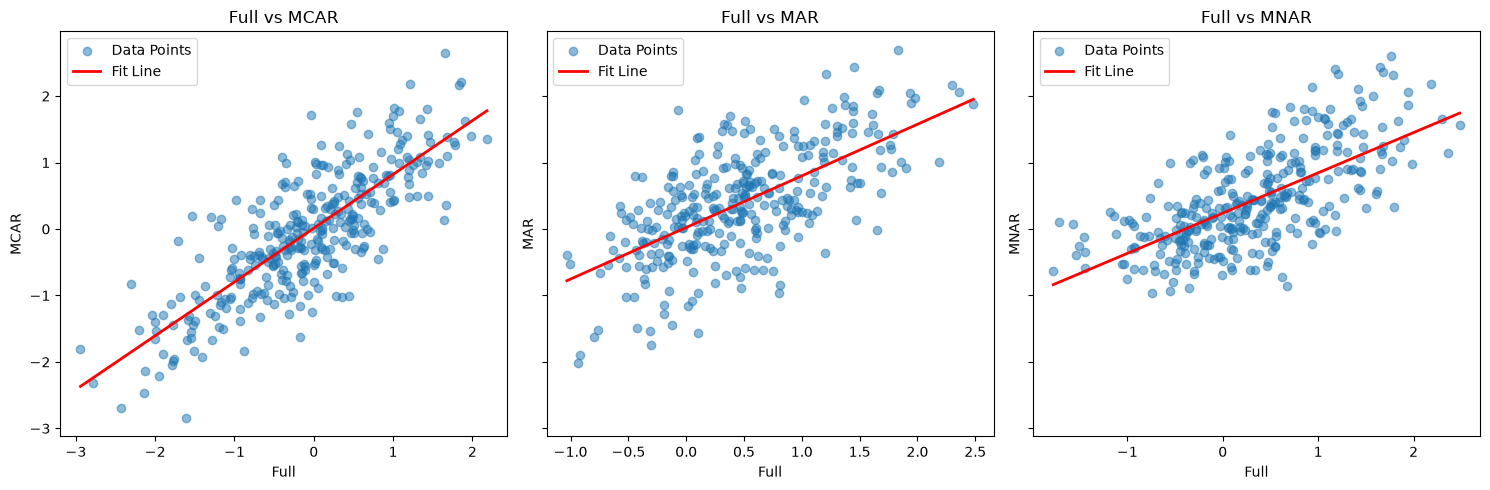

In [12]:
import matplotlib.pyplot as plt

# Create subplots side-by-side for each missingness mechanism
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, var, intercept, slope in zip(axes, VARIABLES, intercepts, slopes):
    pair = toys[["Full", var]].dropna()
    x_vals = pair["Full"]
    y_vals = pair[var]

    # 1. Scatter plot of the data
    ax.scatter(x_vals, y_vals, alpha=0.5, label="Data Points")

    # 2. Plot regression line using calculated slope and intercept
    line_x = np.array([x_vals.min(), x_vals.max()])
    line_y = slope * line_x + intercept
    ax.plot(line_x, line_y, color="red", linewidth=2, label="Fit Line")

    # Formatting
    ax.set_title(f"Full vs {var}")
    ax.set_xlabel("Full")
    ax.set_ylabel(var)
    ax.legend()

plt.tight_layout()
plt.show()

- According to AI MCAR is supposed to be the baseline benchmark.
- MAR stays relatively close to MCAR with minimal change. No significant bias introduced
- MNAR intercept and slope differ significantly from the other 2, MSE and RMSE grew a bit, but $R^2$ went down by quite a bit (over 0.1) suggesting a noticeable bias.

# Ex6.4

In [57]:
survey = pd.read_csv("survey.txt", sep='\t')

clean_survey = survey.copy()
survey = survey.dropna()
display(clean_survey)
# survey.isna().sum()
display(survey)
clean_survey.isna().sum()

,SEX,AGE,RACE,DEGREE,HAPPY,POLVIEWS,nAGE,ISUNHAPPY
0,MALE,31,OTHER,BACHELOR,PRETTY HAPPY,SLIGHTLY LIBERAL,31.0,False
1,FEMALE,23,WHITE,BACHELOR,NOT TOO HAPPY,LIBERAL,23.0,True
2,FEMALE,71,BLACK,LT HIGH SCHOOL,NOT TOO HAPPY,NaN,71.0,True
3,FEMALE,82,WHITE,LT HIGH SCHOOL,NOT TOO HAPPY,LIBERAL,82.0,True
4,FEMALE,78,BLACK,LT HIGH SCHOOL,VERY HAPPY,SLIGHTLY LIBERAL,78.0,False
...,...,...,...,...,...,...,...,...
2039,MALE,62,WHITE,BACHELOR,PRETTY HAPPY,SLGHTLY CONSERVATIVE,62.0,False
2040,FEMALE,66,WHITE,HIGH SCHOOL,NOT TOO HAPPY,EXTRMLY CONSERVATIVE,66.0,True
2041,FEMALE,54,WHITE,HIGH SCHOOL,VERY HAPPY,SLIGHTLY LIBERAL,54.0,False
2042,FEMALE,57,WHITE,BACHELOR,PRETTY HAPPY,SLIGHTLY LIBERAL,57.0,False


,SEX,AGE,RACE,DEGREE,HAPPY,POLVIEWS,nAGE,ISUNHAPPY
0,MALE,31,OTHER,BACHELOR,PRETTY HAPPY,SLIGHTLY LIBERAL,31.0,False
1,FEMALE,23,WHITE,BACHELOR,NOT TOO HAPPY,LIBERAL,23.0,True
3,FEMALE,82,WHITE,LT HIGH SCHOOL,NOT TOO HAPPY,LIBERAL,82.0,True
4,FEMALE,78,BLACK,LT HIGH SCHOOL,VERY HAPPY,SLIGHTLY LIBERAL,78.0,False
5,MALE,40,BLACK,LT HIGH SCHOOL,PRETTY HAPPY,SLIGHTLY LIBERAL,40.0,False
...,...,...,...,...,...,...,...,...
2039,MALE,62,WHITE,BACHELOR,PRETTY HAPPY,SLGHTLY CONSERVATIVE,62.0,False
2040,FEMALE,66,WHITE,HIGH SCHOOL,NOT TOO HAPPY,EXTRMLY CONSERVATIVE,66.0,True
2041,FEMALE,54,WHITE,HIGH SCHOOL,VERY HAPPY,SLIGHTLY LIBERAL,54.0,False
2042,FEMALE,57,WHITE,BACHELOR,PRETTY HAPPY,SLIGHTLY LIBERAL,57.0,False


SEX           0
AGE           3
RACE          0
DEGREE        0
HAPPY         5
POLVIEWS     71
nAGE          3
ISUNHAPPY     5
dtype: int64

In [45]:
print(survey["SEX"].unique())
print(survey["RACE"].unique())
print(survey["DEGREE"].unique())
print(survey["ISUNHAPPY"].unique())
print(survey["POLVIEWS"].unique())

<ArrowStringArray>
['MALE', 'FEMALE']
Length: 2, dtype: str
<ArrowStringArray>
['OTHER', 'WHITE', 'BLACK']
Length: 3, dtype: str
<ArrowStringArray>
['BACHELOR', 'LT HIGH SCHOOL', 'JUNIOR COLLEGE', 'HIGH SCHOOL', 'GRADUATE']
Length: 5, dtype: str
[False True]
<ArrowStringArray>
[    'SLIGHTLY LIBERAL',              'LIBERAL', 'SLGHTLY CONSERVATIVE',
             'MODERATE',    'EXTREMELY LIBERAL',         'CONSERVATIVE',
 'EXTRMLY CONSERVATIVE']
Length: 7, dtype: str


In [46]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
survey["SEX"] = le.fit_transform(survey["SEX"]) #male: 1, female: 0
survey["RACE"] = le.fit_transform(survey["RACE"]) #Black: 0 Other: 1, White: 2
#Bachelor: 0, Graduate: 1, High School: 2, Junior College: 3, LT High School: 4 
survey["DEGREE"] = le.fit_transform(survey["DEGREE"]) 
survey["ISUNHAPPY"] = le.fit_transform(survey["ISUNHAPPY"]) #False: 0, True: 1
#Conservative: 0, Extremely Liberal: 1, Extrmly Conservative: 2, Liberal: 3
#Moderate: 4, , Slightly Conservative: 5, Slightly Liberal: 6
survey["POLVIEWS"] = le.fit_transform(survey["POLVIEWS"])
survey

,SEX,AGE,RACE,DEGREE,HAPPY,POLVIEWS,nAGE,ISUNHAPPY
0,1,31,1,0,PRETTY HAPPY,6,31.0,0
1,0,23,2,0,NOT TOO HAPPY,3,23.0,1
3,0,82,2,4,NOT TOO HAPPY,3,82.0,1
4,0,78,0,4,VERY HAPPY,6,78.0,0
5,1,40,0,4,PRETTY HAPPY,6,40.0,0
...,...,...,...,...,...,...,...,...
2039,1,62,2,0,PRETTY HAPPY,5,62.0,0
2040,0,66,2,2,NOT TOO HAPPY,2,66.0,1
2041,0,54,2,2,VERY HAPPY,6,54.0,0
2042,0,57,2,0,PRETTY HAPPY,6,57.0,0


In [47]:
print(survey["SEX"].unique())
print(survey["RACE"].unique())
print(survey["DEGREE"].unique())
print(survey["ISUNHAPPY"].unique())
print(survey["POLVIEWS"].unique())

[1 0]
[1 2 0]
[0 4 3 2 1]
[0 1]
[6 3 5 4 1 0 2]


In [48]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

unhappy_survey = survey[['ISUNHAPPY', 'SEX', 'nAGE', 'RACE', 'DEGREE', 'POLVIEWS']]



model = smf.logit(
    "ISUNHAPPY ~ C(SEX) + nAGE + C(RACE) + C(DEGREE) + C(POLVIEWS)", 
    data=unhappy_survey
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.409496
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              ISUNHAPPY   No. Observations:                 1969
Model:                          Logit   Df Residuals:                     1954
Method:                           MLE   Df Model:                           14
Date:                Wed, 07 Oct 2026   Pseudo R-squ.:                 0.03457
Time:                        22:02:10   Log-Likelihood:                -806.30
converged:                       True   LL-Null:                       -835.17
Covariance Type:            nonrobust   LLR p-value:                 2.905e-07
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -2.5075      0.343     -7.310      0.000      -3.180      -1.835
C(SEX)[T.1]

## a


- Degree; T.2 (High School) at 0.000 p-value, and T.4 (LT High School) at 0.000 p-value; significantly higher odds of being unhappy compared to T.0 (Bachelor's).
- With a less restrictive threshold like the standard 0.05, we'd see other values like T.2 from race at 0.034 p-value, and T.3 at 0.035 p-value from Degree being significant.

## b

In [67]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean", missing_values=np.nan)

# imputer.fit(clean_survey[["nAGE"]])
# # clean_survey["nAGE"] = imputer.transform(clean_survey[["nAGE"]])

clean_survey["nAGE"] = imputer.fit_transform(clean_survey[["nAGE"]])

In [68]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="most_frequent", missing_values=np.nan)



# imputer.fit(clean_survey)
# imputed = imputer.transform(clean_survey)


imputed = imputer.fit_transform(clean_survey)
clean_survey = pd.DataFrame(imputed, columns=clean_survey.columns)


# clean_survey
clean_survey["nAGE"] = clean_survey["nAGE"].astype(float)



In [69]:
clean_survey.isna().sum()

SEX          0
AGE          0
RACE         0
DEGREE       0
HAPPY        0
POLVIEWS     0
nAGE         0
ISUNHAPPY    0
dtype: int64

In [70]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
clean_survey["SEX"] = le.fit_transform(clean_survey["SEX"]) #male: 1, female: 0
clean_survey["RACE"] = le.fit_transform(clean_survey["RACE"]) #Black: 0 Other: 1, White: 2
#Bachelor: 0, Graduate: 1, High School: 2, Junior College: 3, LT High School: 4 
clean_survey["DEGREE"] = le.fit_transform(clean_survey["DEGREE"]) 
clean_survey["ISUNHAPPY"] = le.fit_transform(clean_survey["ISUNHAPPY"]) #False: 0, True: 1
#Conservative: 0, Extremely Liberal: 1, Extrmly Conservative: 2, Liberal: 3
#Moderate: 4, , Slightly Conservative: 5, Slightly Liberal: 6
clean_survey["POLVIEWS"] = le.fit_transform(clean_survey["POLVIEWS"])
clean_survey

,SEX,AGE,RACE,DEGREE,HAPPY,POLVIEWS,nAGE,ISUNHAPPY
0,1,31,1,0,PRETTY HAPPY,6,31.0,0
1,0,23,2,0,NOT TOO HAPPY,3,23.0,1
2,0,71,0,4,NOT TOO HAPPY,4,71.0,1
3,0,82,2,4,NOT TOO HAPPY,3,82.0,1
4,0,78,0,4,VERY HAPPY,6,78.0,0
...,...,...,...,...,...,...,...,...
2039,1,62,2,0,PRETTY HAPPY,5,62.0,0
2040,0,66,2,2,NOT TOO HAPPY,2,66.0,1
2041,0,54,2,2,VERY HAPPY,6,54.0,0
2042,0,57,2,0,PRETTY HAPPY,6,57.0,0


In [71]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

unhappy_survey_imputed = clean_survey[['ISUNHAPPY', 'SEX', 'nAGE', 'RACE', 'DEGREE', 'POLVIEWS']]



model = smf.logit(
    "ISUNHAPPY ~ C(SEX) + nAGE + C(RACE) + C(DEGREE) + C(POLVIEWS)", 
    data=unhappy_survey_imputed
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.415974
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              ISUNHAPPY   No. Observations:                 2044
Model:                          Logit   Df Residuals:                     2029
Method:                           MLE   Df Model:                           14
Date:                Wed, 07 Oct 2026   Pseudo R-squ.:                 0.03583
Time:                        22:08:57   Log-Likelihood:                -850.25
converged:                       True   LL-Null:                       -881.85
Covariance Type:            nonrobust   LLR p-value:                 3.195e-08
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -2.3459      0.334     -7.033      0.000      -3.000      -1.692
C(SEX)[T.1]

- T.2 (Whites) from race at 0.007 p-value has now become significant, whereas before it was at a 0.034 p-value. And, with its coefficient value of -0.4399 it shows a lower odds of beign unhappy compared to the baselinen. The rest haven't changed enough.